In [2]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

Download the data, if not already on disk and load it as numpy arrays

In [3]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)

# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape
# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]
# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

Total dataset size:
n_samples: 1140
n_features: 1850
n_classes: 5


It is important in machine learning to split the data accordingly into training and testing sets to avoid contamination of the model. Ideally, you should also have a validation set.

In [4]:
# Split into a training set and a test set using a stratified k fold
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# Compute a PCA (eigenfaces) on the face dataset (treated as unlabeled
# dataset): unsupervised feature extraction / dimensionality reduction
n_components = 150
print(X_train)

[[0.17385621 0.18300654 0.25882354 ... 0.04052288 0.06143792 0.07320262]
 [0.7986929  0.7176471  0.5803922  ... 0.19738562 0.24313726 0.3529412 ]
 [0.17254902 0.19084968 0.21176471 ... 0.9111111  0.91764706 0.9398692 ]
 ...
 [0.23137255 0.19869281 0.151634   ... 0.88104576 0.63529414 0.16209151]
 [0.4366013  0.48235294 0.49150327 ... 0.15816994 0.16470589 0.16862746]
 [0.42091504 0.46666667 0.54509807 ... 0.44836602 0.10326798 0.075817  ]]


Compute the PCA via eigen-decomposition of the data matrix X after the mean of the training set is removed. This results in a model with variations from the mean. We also transform the training and testing data into ’face space’, i.e. the learned sub space of the eigen-faces.


In [11]:
# Center data
mean = np.mean(X_train, axis=0)
X_train -= mean
X_test -= mean
#Eigen-decomposition
U, S, V = np.linalg.svd(X_train, full_matrices=False)
components = V[:n_components]
eigenfaces = components.reshape((n_components, h, w))
#project into PCA subspace
X_transformed = np.dot(X_train, components.T)
print(X_transformed.shape)
X_test_transformed = np.dot(X_test, components.T)
print(X_test_transformed.shape)


(855, 150)
(285, 150)


Finally, plot the resulting eigen-vectors of the face PCA model, AKA the eigenfaces

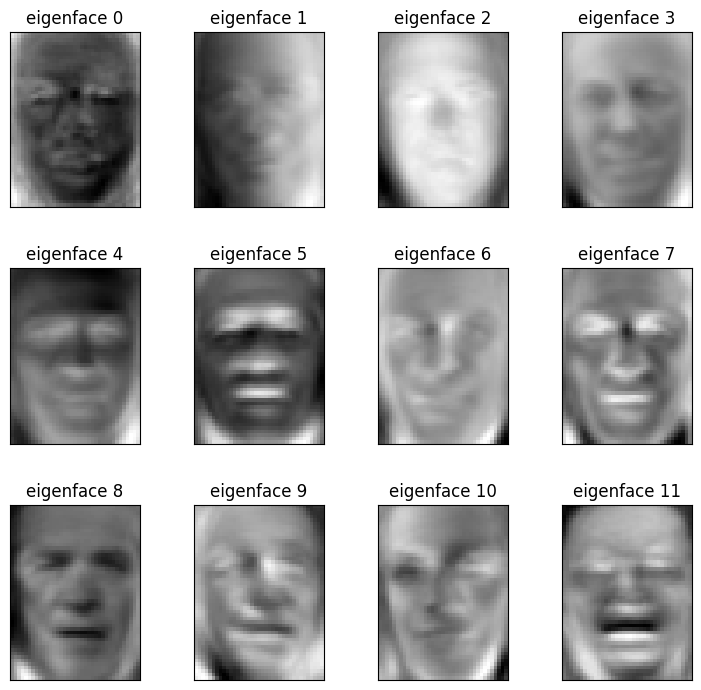

In [12]:

import matplotlib.pyplot as plt
# Qualitative evaluation of the predictions using matplotlib
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()


We should always evaluate the performance of the dimensionality reduction via a compactness plot

(855,)


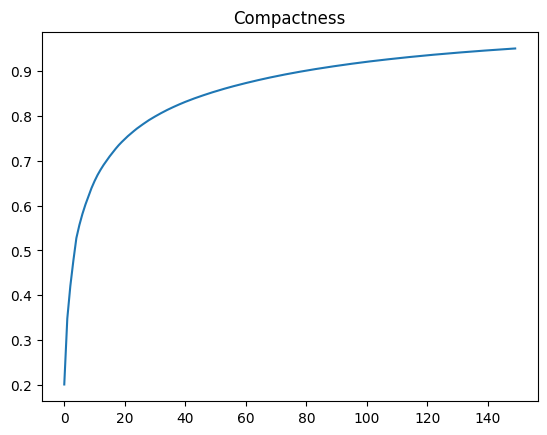

In [13]:

explained_variance = (S ** 2) / (n_samples - 1)
total_var = explained_variance.sum()
explained_variance_ratio = explained_variance / total_var
ratio_cumsum = np.cumsum(explained_variance_ratio)
print(ratio_cumsum.shape)
eigenvalueCount = np.arange(n_components)

plt.plot(eigenvalueCount, ratio_cumsum[:n_components])
plt.title('Compactness')
plt.show()

Use the PCA ’face space’ as features and build a random forest classifier to classify the faces accord-
ing to the labels. We then view its classification performance.

In [14]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
#build random forest
estimator = RandomForestClassifier(n_estimators=150, max_depth=15, max_features=150)
estimator.fit(X_transformed, y_train) #expects X as [n_samples, n_features]

predictions = estimator.predict(X_test_transformed)
correct = predictions==y_test
total_test = len(X_test_transformed)
#print("Gnd Truth:", y_test)
print("Total Testing", total_test)
print("Predictions", predictions)
print("Which Correct:",correct)
print("Total Correct:",np.sum(correct))
print("Accuracy:",np.sum(correct)/total_test)
print(classification_report(y_test, predictions, target_names=target_names, zero_division=0.0))

Total Testing 285
Predictions [2 0 2 3 2 2 2 4 2 2 2 2 2 0 2 0 4 4 2 0 2 2 2 4 2 4 2 2 2 2 3 3 2 0 0 2 2
 0 3 2 2 2 2 2 2 4 0 3 2 2 0 0 2 0 2 2 2 2 2 4 2 2 2 0 0 2 3 2 0 2 4 2 1 4
 2 2 2 4 2 2 2 2 2 2 3 2 2 2 2 2 2 2 2 4 2 0 2 0 2 3 2 3 2 3 2 1 2 2 2 2 2
 2 2 1 2 2 2 1 2 2 2 0 2 0 2 2 2 1 2 2 2 1 2 0 4 2 3 4 0 2 2 0 2 2 2 0 4 2
 2 2 2 2 2 0 2 3 4 2 2 4 0 2 1 1 2 2 2 0 2 0 1 2 2 2 0 2 2 2 2 2 4 2 4 2 2
 2 2 2 2 2 2 2 2 2 0 0 2 2 0 2 2 2 0 3 2 2 0 2 0 2 2 4 2 4 2 4 2 2 2 2 2 3
 0 2 1 2 0 1 2 2 2 0 2 2 2 4 2 0 2 2 3 2 2 2 2 0 2 2 0 2 3 0 0 3 2 2 1 2 2
 2 3 2 2 0 4 2 4 2 4 3 2 3 2 1 0 2 4 2 0 3 2 0 2 2 4]
Which Correct: [False  True  True  True  True  True False  True  True  True False  True
 False  True  True  True  True  True  True  True False  True False  True
  True  True False  True  True False  True False False  True  True False
  True  True  True False  True  True False  True  True False  True False
  True False False  True  True  True  True  True  True  True  True False
  True  Tru